# 01 — Data Quality & Exploration

First look at the engineered feature table. Goal: decide what's usable before committing to a Postgres schema or a forecaster.

Sections:
1. Load & shape
2. Coverage (sources, cities, hotels, dates)
3. Missing-value rates
4. Cardinality (room/boarding strings)
5. Price distributions
6. Booking-window effect (price vs. days_until_checkin)
7. Weekend effect
8. Engineered-feature sanity (competitor_avg, delta_pct, sea_view_premium)
9. Temporal coverage (scraped_at)

In [1]:
import sys
from pathlib import Path

# Make the ml/ package importable from this notebook.
ML_ROOT = Path.cwd().resolve().parents[0]
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

from feature_engineering.build_features import build_features

## 1. Load & shape

In [2]:
df = build_features(source="mongo")
print(df.shape)
df.head(3)

(1528628, 35)


,source,scraped_at,scrape_run_id,check_in,check_out,nights,days_until_checkin,city_id,city_name,adults,children,hotel_name,stars,boarding_name,room_name,price,sur_demande,supplements,hotel_name_normalized,price_per_night,stars_int,has_supplement,free_supplement,total_supplement_price,check_in_date,day_of_week,month,weekend_flag,is_sea_view,is_garden_view,competitor_avg_price,price_delta_pct,price_rank_in_city,city_competitor_count,sea_view_premium
0,tunisiepromo,2026-04-17T09:24:44.980441+00:00,2158d76f86a9,2026-09-01,2026-09-04,3,137,12,kelibia,2,0,Cap Bon Kelibia Beach Hotel & Spa,4,Demi Pension Plus,Chambre RDC Vue Mer,2238.696045,False,[],cap bon kelibia beach hotel spa,746.229980,4,False,False,0.0,2026-09-01,1,9,0,1,0,756.381653,-1.342136,5,7,NaN
1,tunisiepromo,2026-04-17T09:24:44.980441+00:00,2158d76f86a9,2026-09-01,2026-09-04,3,137,12,kelibia,2,0,Cap Bon Kelibia Beach Hotel & Spa,4,Demi Pension Plus,Chambre Double Vue Mer,2094.263916,False,[],cap bon kelibia beach hotel spa,698.090027,4,False,False,0.0,2026-09-01,1,9,0,1,0,764.405029,-8.675375,3,7,NaN
2,tunisiepromo,2026-04-17T09:24:44.980441+00:00,2158d76f86a9,2026-09-01,2026-09-04,3,137,12,kelibia,2,0,Cap Bon Kelibia Beach Hotel & Spa,4,Demi Pension Plus,Chambre Double Standard,1877.615967,False,[],cap bon kelibia beach hotel spa,625.869995,4,False,False,0.0,2026-09-01,1,9,0,0,0,776.441650,-19.392527,1,7,NaN


In [3]:
df.dtypes

source                            object
scraped_at                        object
scrape_run_id                     object
check_in                          object
check_out                         object
nights                             int64
days_until_checkin                 Int16
city_id                            int64
city_name                         object
adults                             int64
children                           int64
hotel_name                        object
stars                             object
boarding_name                     object
room_name                         object
price                            float32
sur_demande                         bool
supplements                       object
hotel_name_normalized             object
price_per_night                  float32
stars_int                           Int8
has_supplement                      bool
free_supplement                     bool
total_supplement_price           float32
check_in_date   

## 2. Coverage

In [4]:
print("Rows per source:")
print(df["source"].value_counts())
print("\nRows per city (top 10):")
print(df["city_name"].value_counts().head(10))

Rows per source:
source
tunisiepromo    1221406
promohotel       307222
Name: count, dtype: int64

Rows per city (top 10):
city_name
hammamet          333907
tunis             285864
djerba            219034
sousse            210491
monastir          107838
tozeur             63407
tabarka            61489
mahdia             55337
tunis-gammarth     41285
sfax               34724
Name: count, dtype: int64


In [5]:
# Hotels with coverage in both sources vs only one.
hotels_per_source = df.groupby("hotel_name_normalized")["source"].nunique()
print("Hotels in BOTH sources:", (hotels_per_source == 2).sum())
print("Hotels in ONE source only:", (hotels_per_source == 1).sum())

Hotels in BOTH sources: 66
Hotels in ONE source only: 424


count      490.000000
mean      3119.648980
std       3076.880197
min         78.000000
25%       1092.000000
50%       2116.500000
75%       4117.250000
max      21514.000000
dtype: float64


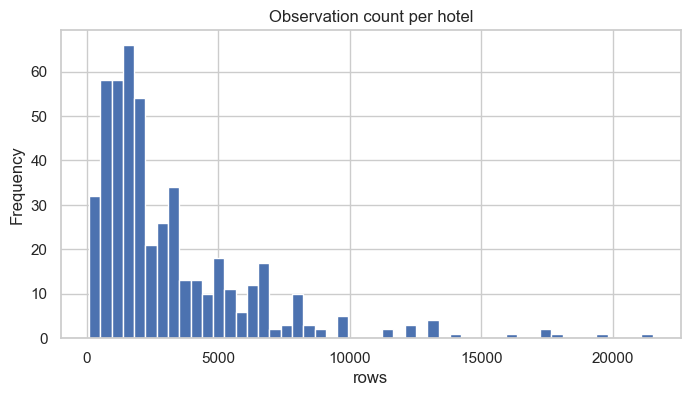

In [6]:
# Hotel observation counts — long-tail check.
hotel_counts = df.groupby("hotel_name_normalized").size().sort_values(ascending=False)
print(hotel_counts.describe())

plt.figure(figsize=(8, 4))
hotel_counts.plot.hist(bins=50)
plt.title("Observation count per hotel")
plt.xlabel("rows")
plt.show()

## 3. Missing-value rates

In [7]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

sea_view_premium        85.905008
stars                    3.814401
stars_int                3.814401
price_delta_pct          0.827016
competitor_avg_price     0.827016
dtype: float64

## 4. Cardinality — how messy are the string fields?

In [8]:
print("Unique room_name values:", df["room_name"].nunique())
print("Unique boarding_name values:", df["boarding_name"].nunique())
print("\nTop 15 room names:")
print(df["room_name"].value_counts().head(15))
print("\nTop 15 boarding names:")
print(df["boarding_name"].value_counts().head(15))

Unique room_name values: 706
Unique boarding_name values: 23

Top 15 room names:
room_name
Chambre Double               143292
Chambre Standard             141974
Chambre double               137520
Chambre Double Vue Mer        57634
Suite Junior                  47085
Chambre Vue Mer               44621
Suite                         26171
Chambre supérieure            18524
Chambre Double Supérieure     16695
Chambre Vue Piscine           16528
Chambre Double Standard       16048
Suite Présidentielle          15072
Chambre double vue mer        14618
Chambre Supérieure            12207
Chambre Exécutive             11824
Name: count, dtype: int64

Top 15 boarding names:
boarding_name
Petit Déjeuner              327162
Demi Pension                252810
Soft All Inclusive          222242
All Inclusive               185931
Pension Complète            168092
Soft All inclusive          106842
Logement Simple              53987
Logement Petit dejeuner      48376
Demi pension             

In [9]:
# Are the same concepts written differently across sources?
pd.crosstab(df["source"], df["boarding_name"]).T

source,promohotel,tunisiepromo
boarding_name,,
All In Hard,0,117
All Inclusive,62128,123803
All Inclusive GOLD,0,420
All Inclusive Soft Drink,0,6402
Demi Pension,0,252810
Demi Pension +,0,810
Demi Pension Plus,9073,32450
Demi pension,47033,0
Entrée simple,0,3096


## 5. Price distributions

count    1.528628e+06
mean     7.116157e+02
std      6.562239e+02
min      3.277000e+01
25%      3.607300e+02
50%      5.692500e+02
75%      8.549100e+02
max      1.761362e+04
Name: price_per_night, dtype: float64


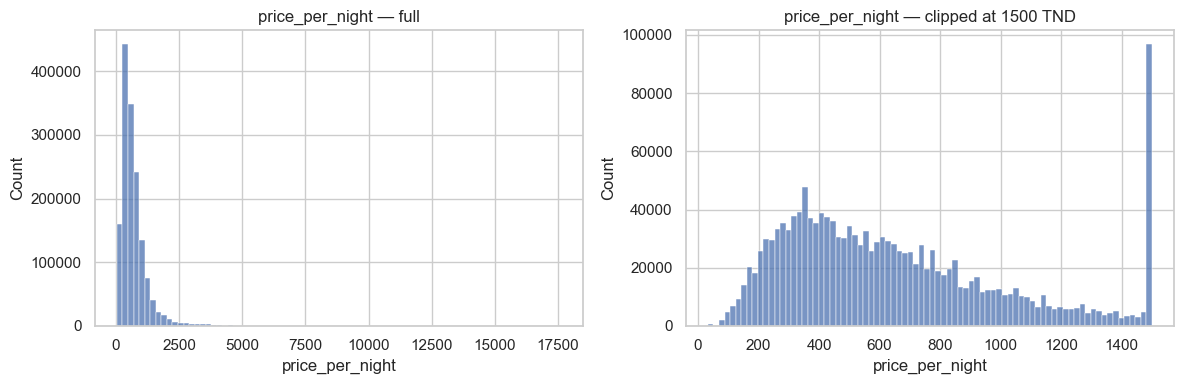

In [10]:
print(df["price_per_night"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price_per_night"], bins=80, ax=axes[0])
axes[0].set_title("price_per_night — full")
sns.histplot(df["price_per_night"].clip(0, 1500), bins=80, ax=axes[1])
axes[1].set_title("price_per_night — clipped at 1500 TND")
plt.tight_layout()
plt.show()

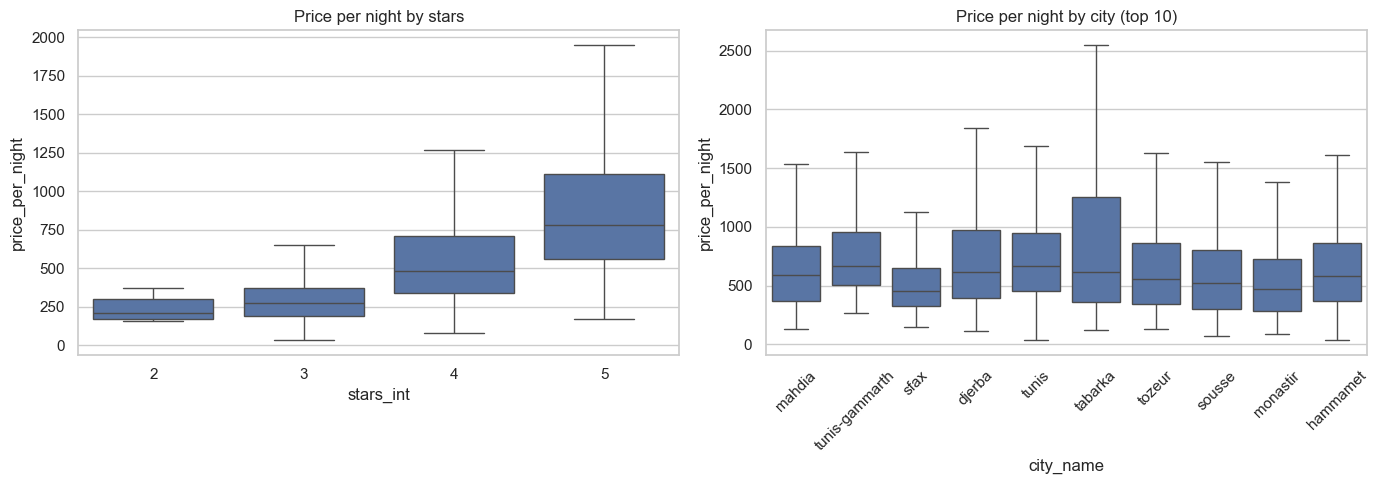

In [11]:
# Price by stars and by city.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="stars_int", y="price_per_night", ax=axes[0], showfliers=False)
axes[0].set_title("Price per night by stars")

top_cities = df["city_name"].value_counts().head(10).index
sns.boxplot(
    data=df[df["city_name"].isin(top_cities)],
    x="city_name", y="price_per_night", ax=axes[1], showfliers=False,
)
axes[1].set_title("Price per night by city (top 10)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Outlier check: extreme low and extreme high.
print("Bottom 0.5% threshold:", df["price_per_night"].quantile(0.005))
print("Top 0.5% threshold:   ", df["price_per_night"].quantile(0.995))

print("\nSample of suspiciously cheap rows (<30 TND/night):")
df.loc[df["price_per_night"] < 30, ["source", "hotel_name", "stars", "room_name", "boarding_name", "price_per_night"]].head(10)

Bottom 0.5% threshold: 104.87999725341797
Top 0.5% threshold:    3787.909912109375

Sample of suspiciously cheap rows (<30 TND/night):


,source,hotel_name,stars,room_name,boarding_name,price_per_night


## 6. Booking-window effect

The project hypothesis says Tunisian travel markets show price inversion — last-minute cheaper than advance booking. Let's see it.

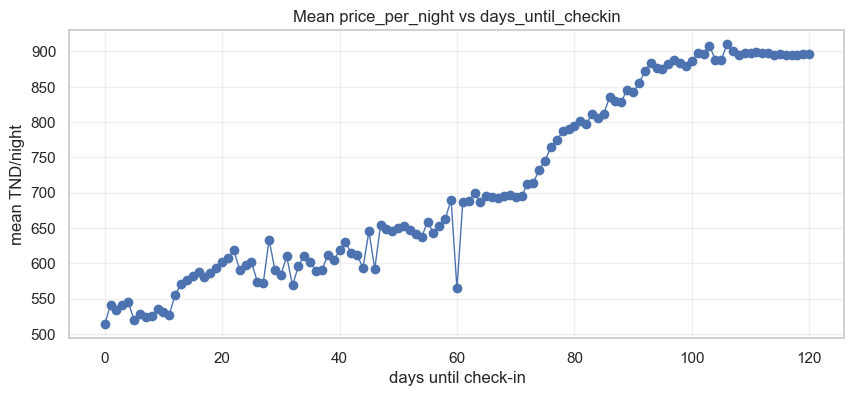

In [13]:
# Mean price_per_night binned by days_until_checkin.
window = (
    df[df["days_until_checkin"].between(0, 120)]
      .groupby("days_until_checkin")["price_per_night"].mean()
)

plt.figure(figsize=(10, 4))
window.plot(marker="o", linewidth=1)
plt.title("Mean price_per_night vs days_until_checkin")
plt.xlabel("days until check-in")
plt.ylabel("mean TND/night")
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


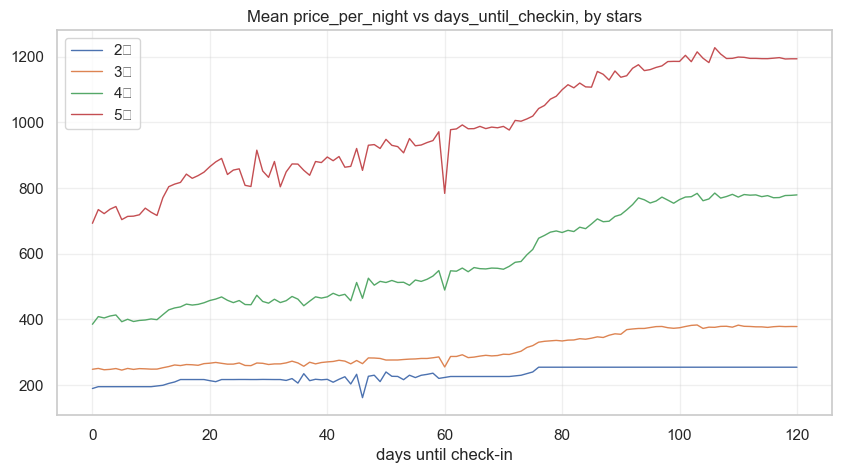

In [14]:
# Same, split by stars — does inversion hold across tiers?
plt.figure(figsize=(10, 5))
for stars, group in df[df["days_until_checkin"].between(0, 120)].groupby("stars_int"):
    if len(group) < 100:
        continue
    series = group.groupby("days_until_checkin")["price_per_night"].mean()
    plt.plot(series.index, series.values, label=f"{stars}★", linewidth=1)
plt.legend()
plt.title("Mean price_per_night vs days_until_checkin, by stars")
plt.xlabel("days until check-in")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Weekend effect

                    mean      median    count
weekend_flag                                 
0             711.275269  569.049988  1088397
1             712.456726  569.940002   440231


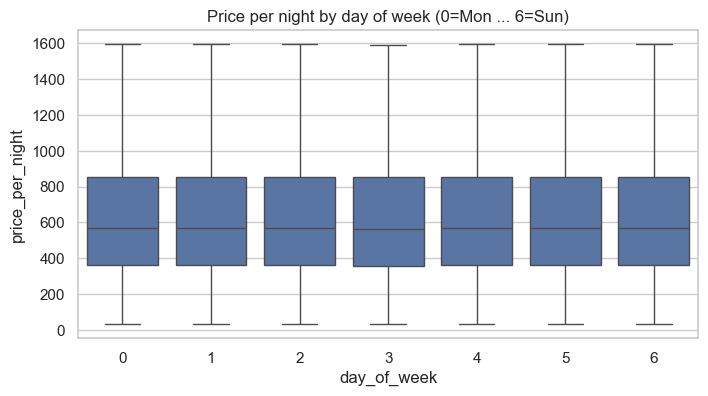

In [15]:
print(df.groupby("weekend_flag")["price_per_night"].agg(["mean", "median", "count"]))

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="day_of_week", y="price_per_night", showfliers=False)
plt.title("Price per night by day of week (0=Mon ... 6=Sun)")
plt.show()

## 8. Engineered-feature sanity

In [16]:
print("competitor_avg_price coverage:", df["competitor_avg_price"].notna().mean())
print("sea_view_premium coverage:   ", df["sea_view_premium"].notna().mean())

print("\nprice_delta_pct (should be centered near 0):")
print(df["price_delta_pct"].describe())

competitor_avg_price coverage: 0.9917298387835366
sea_view_premium coverage:    0.14094992372244916

price_delta_pct (should be centered near 0):
count    1.515986e+06
mean     1.367183e+00
std      7.118164e+01
min     -8.992509e+01
25%     -3.813479e+01
50%     -1.385038e+01
75%      2.134624e+01
max      1.250394e+03
Name: price_delta_pct, dtype: float64


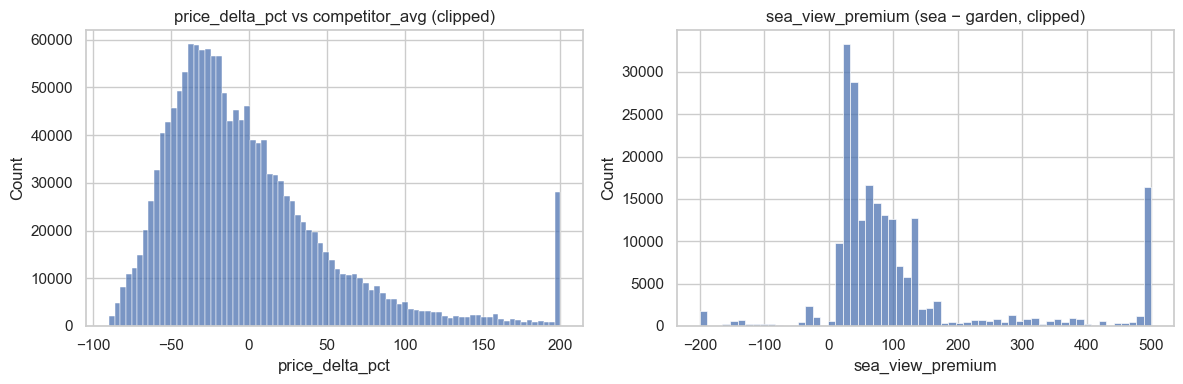

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price_delta_pct"].clip(-100, 200), bins=80, ax=axes[0])
axes[0].set_title("price_delta_pct vs competitor_avg (clipped)")
sns.histplot(df["sea_view_premium"].dropna().clip(-200, 500), bins=60, ax=axes[1])
axes[1].set_title("sea_view_premium (sea − garden, clipped)")
plt.tight_layout()
plt.show()

## 9. Temporal coverage

In [18]:
# When were the scrapes that produced this data?
scraped = pd.to_datetime(df["scraped_at"], errors="coerce")
print("scraped_at range:", scraped.min(), "->", scraped.max())
print("\nScrapes per day:")
print(scraped.dt.date.value_counts().sort_index())

scraped_at range: 2026-04-15 14:41:00.124724+00:00 -> 2026-04-17 09:24:44.980441+00:00

Scrapes per day:
scraped_at
2026-04-15      43923
2026-04-16    1037423
2026-04-17     447282
Name: count, dtype: int64


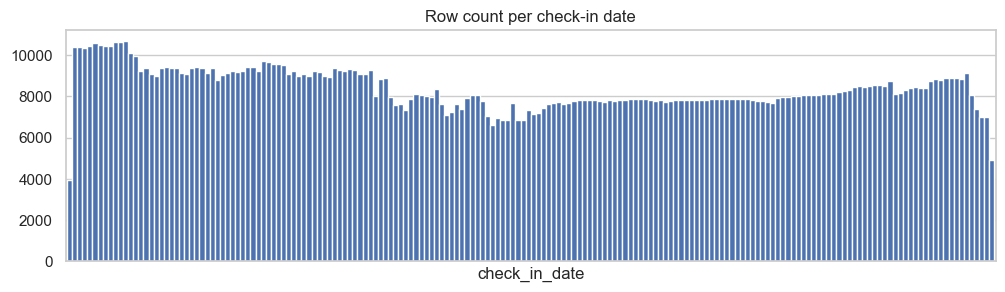

In [19]:
# Check-in date coverage — are there gaps in the future?
plt.figure(figsize=(12, 3))
df["check_in_date"].value_counts().sort_index().plot(kind="bar", width=1.0)
plt.title("Row count per check-in date")
plt.xticks([])
plt.show()

## Notes

Use the cells above as a starting point — add your own checks as questions come up. Findings that should shape the schema or the forecaster go in `02_*.ipynb` or into project memory.